In [119]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [120]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/TDM_T1_varyloss1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

/tmp/ipykernel_3496367/2599803745.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


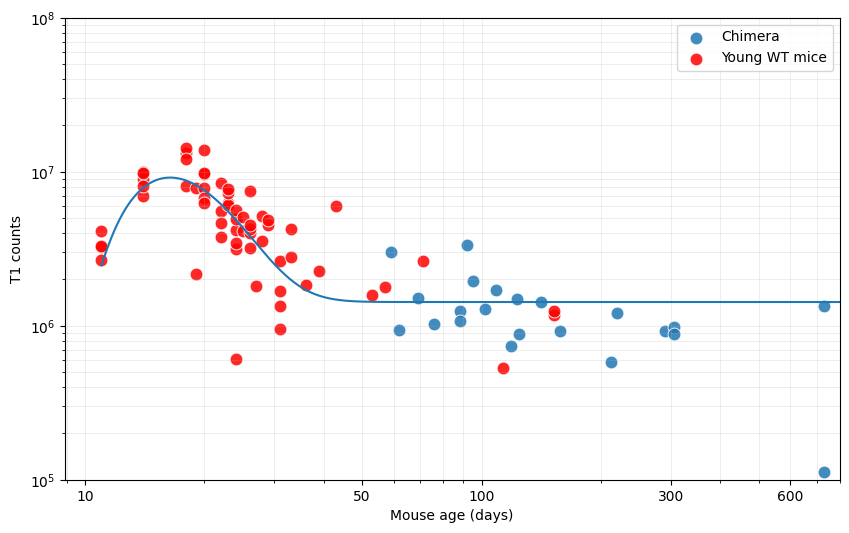

In [121]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [122]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def delta(t):
    r_d = np.mean(data_neutral.r_d)
    delta = np.mean(data_neutral.delta)
    delta_var = delta *np.exp(-r_d*(t-40))
    return delta_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi * P(t) + rho * M - delta(t) * M
    return np.array(dMdt)


# Define the parameters as array
phi = np.mean(data_neutral.phi)
rho = np.mean(data_neutral.rho)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta, P))
print(sol.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [40, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
#     sol[i, :] = result.y[0]

# print(sol.shape)
# print(M0)



[[  12058.           12092.63630926   12127.29688635 ... 2128130.15187287
  2128129.64764013 2128129.14340743]]


/tmp/ipykernel_3496367/439309075.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


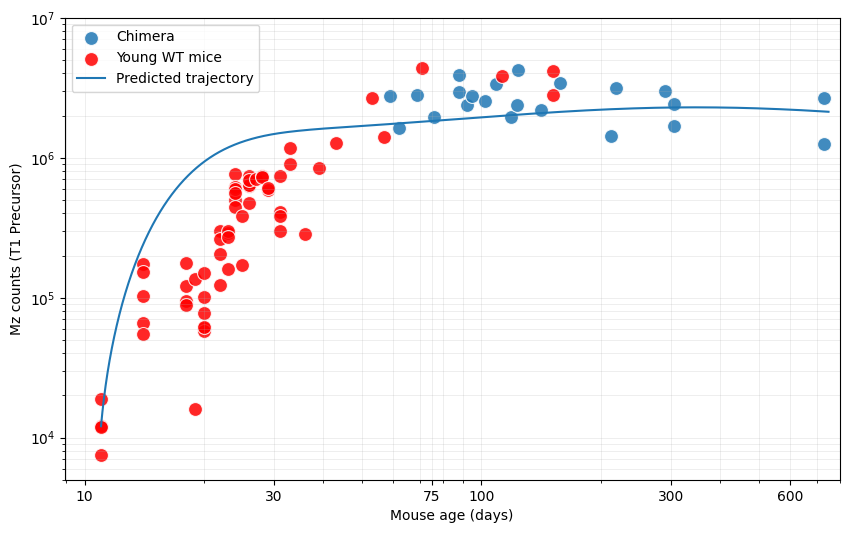

In [123]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



In [145]:
def P(t):
    theta_0 = np.exp(14)
    nu = 0.29
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 0.1
    phi = 0.014
    # phi_var =  (phi / (1 + np.exp((-r_phi) * (t-25))))

    phi_var = phi*(1 - np.exp(-r_phi * (t)))
 
    return phi_var

def delta(t):
    r_d = np.mean(data_neutral.r_d)
    delta = np.mean(data_neutral.delta)
    delta_var = delta *np.exp(-r_d*(t-40))
    return delta_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho * M - delta(t) * M
    return np.array(dMdt)


# Define the parameters as array
# phi = np.mean(data_neutral.phi)
rho = np.mean(data_neutral.rho)

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta, P))
print(sol_1.y)


[[  12058.           12077.54795595   12097.11195838 ... 1899077.63764328
  1899078.6333232  1899079.62899071]]


/tmp/ipykernel_3496367/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


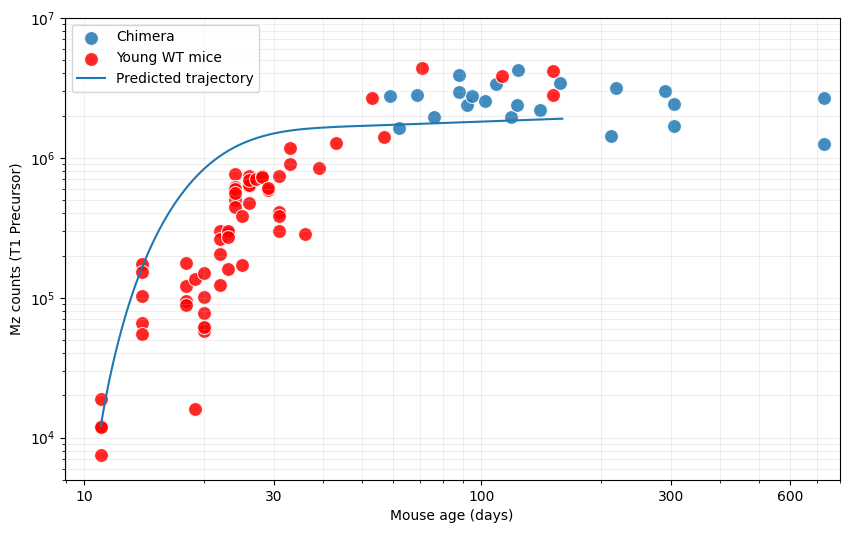

In [146]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [126]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta(t):
    r_d = np.mean(data_neutral.r_d)  # Define r_d as the mean of data_neutral.r_d
    delta1 = np.mean(data_neutral.delta)
    if t < 40:
        delta_var = delta1 * (1 - np.exp(1.5 * (t - 40)))
    else:
        delta_var = delta1 * np.exp(-r_d * (t - 40))
    return delta_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi * P(t) + rho * M - delta(t) * M
    return np.array(dMdt)


# Define the parameters as array
phi = np.mean(data_neutral.phi)
rho = np.mean(data_neutral.rho)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 152, 0.001)

sol = solve_ivp(ode_function, [11, 152], M0, t_eval=t_ev, args=(phi, rho, delta, P))
print(sol.y)


[[  12058.           12092.63555995   12127.29538561 ... 2109767.58643582
  2109770.05469891 2109772.52293699]]


/tmp/ipykernel_3496367/2847097745.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


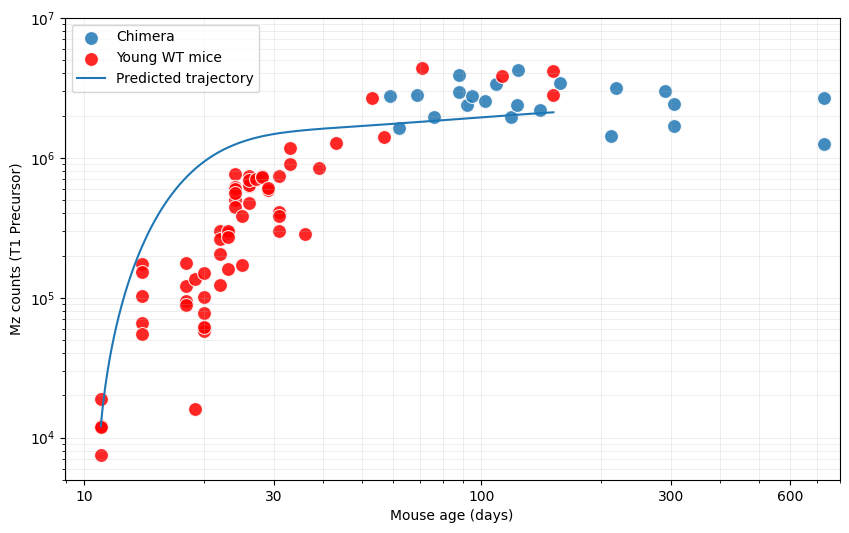

In [127]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [128]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()



TypeError: 'numpy.float64' object is not callable

<Figure size 1000x600 with 0 Axes>